# Guide02: Transform the Data

Second of six notebooks on one running example: predicting Ames house prices. This one covers **Stage 6** of the [13-stage workflow](../Guide00_Supervised-ML_Linear_Regression_end-to-end_workflow.md): turning the cleaned, split data from `Guide01` into a numeric, complete, well-behaved matrix a linear model can use, without leaking anything from the test set.

**Prerequisite:** `Guide01_Supervised-ML_Linear-Regression_Define-Understand-Clean-Split-Explore.ipynb`.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

assert tuple(int(p) for p in sklearn.__version__.split(".")[:2]) >= (1, 1), \
    "This notebook needs scikit-learn 1.1 or newer (OneHotEncoder's min_frequency). " \
    "Run: pip install -U scikit-learn"

pd.set_option("display.max_columns", 15)
plt.rcParams["figure.figsize"] = (7, 4)


---
## Recap: Where `Guide01` Left Off

Rebuild the cleaned, split data exactly as `Guide01` produced it. This is why `load_ames`, `clean_ames`, and `split_ames` live in `pipeline/ames_workflow.py` rather than only inside `Guide01`'s own cells: every later guide can recreate the same state in three lines.

We still receive `X_test` and `y_test` here -- but this notebook never touches them. That discipline continues through `Guide05`; only `Guide06` opens the test set.


In [2]:
from pipeline.ames_workflow import load_ames, clean_ames, split_ames

X_train, X_test, y_train, y_test = split_ames(clean_ames(load_ames()))
print(f"train: {X_train.shape}   test (locked, not used below): {X_test.shape}")


train: (1213, 79)   test (locked, not used below): (164, 79)


**`Guide01`'s Stage 6 to-do list**, for reference:

* Transform the target (`SalePrice` is skewed).
* Encode roughly 43 categorical columns, including ordinal quality grades and `MSSubClass`.
* Group rare categories before one-hot encoding.
* Expect collinearity among the garage and living-area features.
* Build and test an imputer, even though this particular file has no genuinely missing values.

This notebook works through that list in order: impute, encode, engineer, transform the target, scale.


---
## Stage 6.1: Handle Missing Values

`Guide01` established that every "missing" cell in this file is really the category `"None"` -- there is nothing to impute here. But real projects usually do have genuine gaps, so it is worth practicing the mechanics on a **labelled simulation**: we manufacture missing values ourselves, so we know exactly what the "correct" fill value should have been, and can catch it if a leaky approach gets it wrong.


In [3]:
rng = np.random.default_rng(42)

X_train_sim = X_train.copy()
for col in ["GrLivArea", "LotArea"]:
    missing_idx = rng.choice(X_train_sim.index, size=int(0.05 * len(X_train_sim)), replace=False)
    X_train_sim.loc[missing_idx, col] = np.nan

print(X_train_sim[["GrLivArea", "LotArea"]].isna().sum())


GrLivArea    60
LotArea      60
dtype: int64


Now split this simulated training data once more, into a smaller "fit" slice and a "validation" slice -- standing in for the training/test split itself, one level down. Compare the median computed the **correct** way (fit slice only) against the **leaky** way (peeking at the validation slice too):


In [4]:
from sklearn.model_selection import train_test_split

X_fit, X_val = train_test_split(X_train_sim, test_size=0.25, random_state=42)

for col in ["GrLivArea", "LotArea"]:
    correct = X_fit[col].median()
    leaky = pd.concat([X_fit, X_val])[col].median()
    print(f"{col:10s} correct (fit only): {correct:>8.0f}   leaky (fit + peeked val): {leaky:>8.0f}")


GrLivArea  correct (fit only):     1478   leaky (fit + peeked val):     1481
LotArea    correct (fit only):     9600   leaky (fit + peeked val):     9587


The gap is small here, because `X_fit` and `X_val` are just two random samples from the same population -- but it is not zero, and the mechanism is what matters, not the size of the gap in this particular case. With a less homogeneous dataset, or a time-based split like ours, the same mistake can move the fill value a lot. Any amount of leakage makes an evaluation number a little bit of a lie.

`SimpleImputer` enforces the correct version for you: `.fit()` on training data only, `.transform()` everywhere else. That is exactly what the numeric branch of `build_preprocessor()` (assembled at the end of this notebook) does -- and here it will simply never fire, since `X_train` itself has nothing to fill.


---
## Stage 6.2: Encode Categorical Features

Two kinds of category, two techniques.

### Ordinal: one shared quality scale

Ten columns each grade a feature on the same scale, worst to best:


In [5]:
from pipeline.ames_workflow import QUALITY_COLS, QUALITY_SCALE

print("scale:", QUALITY_SCALE)
print(f"columns ({len(QUALITY_COLS)}):", QUALITY_COLS)
X_train[QUALITY_COLS].head(3)


scale: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
columns (10): ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC
0,Gd,TA,Gd,TA,Ex,Gd,None,TA,TA,None
1,TA,TA,Gd,TA,Ex,TA,TA,TA,TA,None
2,Gd,TA,Gd,TA,Ex,Gd,TA,TA,TA,None


`"None"` sits at the *bottom* of the scale, below `"Po"` (poor) -- treating "no such feature" as worse than a poor one is a simplification (a more careful design might keep a separate "has this feature at all" indicator), but it is a reasonable one for a first pass, and we say so explicitly rather than let it pass unremarked.

A few other columns are also mildly ordinal -- `LotShape` (regular to irregular), `Functional` (typical to severely damaged), `GarageFinish` (unfinished to finished) -- each on its *own* scale. To keep this notebook focused on one clean pattern, we treat those as nominal below; mapping them properly is a good exercise for later.

### Nominal: one-hot, with rare categories grouped

Every other text column has no natural order -- `Neighborhood`, `SaleType`, and so on -- so each gets its own 0/1 column per category. Some categories are rare:


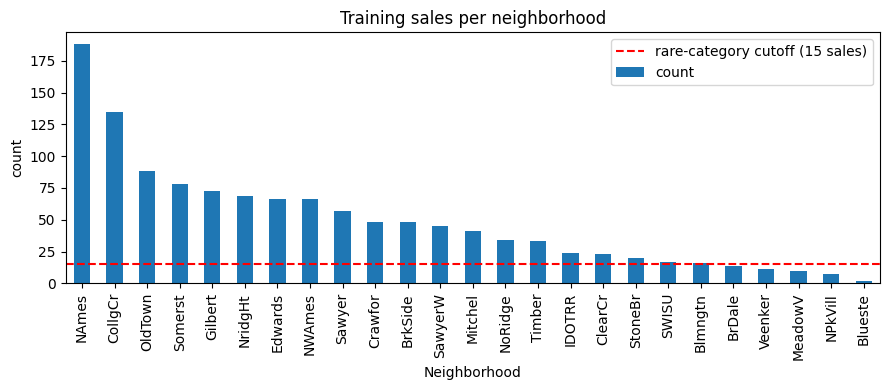

5 of 25 neighborhoods have fewer than 15 sales in training


In [6]:
neighborhood_counts = X_train["Neighborhood"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
neighborhood_counts.plot.bar(ax=ax)
ax.axhline(15, color="red", ls="--", label="rare-category cutoff (15 sales)")
ax.set(title="Training sales per neighborhood", ylabel="count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{(neighborhood_counts < 15).sum()} of {len(neighborhood_counts)} neighborhoods have fewer than 15 sales in training")


One-hot encoding every one of those rare neighborhoods as its own column would give the model almost nothing to learn each of their coefficients from. `scikit-learn`'s `OneHotEncoder` has a built-in fix: `min_frequency` pools every category below the threshold into one shared "infrequent" column -- and, importantly, the threshold is learned from **training data counts only**, so it is safe to fit inside the same pipeline as everything else.


In [7]:
from sklearn.preprocessing import OneHotEncoder

demo_encoder = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=15)
demo_encoder.fit(X_train[["Neighborhood"]])
print("grouped into 'infrequent':", demo_encoder.infrequent_categories_[0].tolist())


grouped into 'infrequent': ['Blueste', 'BrDale', 'MeadowV', 'NPkVill', 'Veenker']


---
## Stage 6.3: Engineer Features

Two domain-driven columns, both plain arithmetic on existing columns -- they learn nothing from the data, so, unlike every other technique in this notebook, they are safe to compute the same way on training and test data independently.


In [8]:
from pipeline.ames_workflow import add_engineered_features

X_train_eng = add_engineered_features(X_train)
print(X_train_eng[["YrSold", "YearBuilt", "HouseAge", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head(3))
print("\nHouseAge range:", X_train_eng.HouseAge.min(), "to", X_train_eng.HouseAge.max(), "years")


   YrSold  YearBuilt  HouseAge  TotalBsmtSF  1stFlrSF  2ndFlrSF  TotalSF
0    2008       2003         5        856.0     856.0     854.0   2566.0
1    2007       1976        31       1262.0    1262.0       0.0   2524.0
2    2008       2001         7        920.0     920.0     866.0   2706.0

HouseAge range: 0 to 129 years


Worth checking: does a new engineered feature correlate strongly with something already in the data?


In [9]:
print("TotalSF vs GrLivArea correlation:", round(X_train_eng.TotalSF.corr(X_train_eng.GrLivArea), 2))


TotalSF vs GrLivArea correlation: 0.86


Yes, closely -- unsurprising, since both measure the size of the house from slightly different angles. That is a second source of multicollinearity, on top of the feature pairs `Guide01` already found (`GarageArea`/`GarageCars`, and others). We do not fix it here; it is exactly what regularization (`Guide05`) is for. Engineering a useful new feature does not have to mean avoiding all correlation with what is already there.


---
## Stage 6.4: Transform the Target

`Guide01` found `SalePrice` skewed (about 1.9). Compare two fixes on the training target, using the actual data rather than assuming:


In [10]:
from scipy import stats

y_log = np.log(y_train)
y_boxcox, boxcox_lambda = stats.boxcox(y_train)

print(f"raw SalePrice   skew: {stats.skew(y_train):.2f}")
print(f"log(SalePrice)  skew: {stats.skew(y_log):.2f}")
print(f"Box-Cox(lambda={boxcox_lambda:.2f}) skew: {stats.skew(y_boxcox):.2f}")


raw SalePrice   skew: 1.92
log(SalePrice)  skew: 0.30
Box-Cox(lambda=-0.21) skew: -0.02


Box-Cox's own optimal `lambda` lands at about -0.21, not near 0 -- so, unlike some datasets, log is *not* the same thing as this target's best Box-Cox fit. Box-Cox does get closer to symmetric (skew near 0) than log (skew about 0.3). The trade-off: Box-Cox needs its `lambda` saved and `scipy.special.inv_boxcox` to invert, while log inverts with a plain `np.exp`.

We use **log** for the rest of this guide series: skew 0.3 is a solid improvement over 1.9, and the simpler inverse is worth more, this early in the series, than squeezing out the last bit of symmetry. Box-Cox is a reasonable thing to try later, once the rest of the workflow is familiar -- this is also this notebook's "your turn" option B, below.

**Save nothing else here** -- log needs no parameter to invert, unlike Box-Cox's `lambda`. `np.log` to transform, `np.exp` to convert predictions back to dollars, in every later guide.


---
## Stage 6.5: Scale the Features

Standardizing (zero mean, unit variance) does not change what an *unregularized* linear regression predicts -- but `Guide05`'s Ridge and Lasso penalize every coefficient's size equally, so features measured in wildly different units (square feet in the thousands, `OverallQual` from 1 to 10) need to be on comparable scales first. A quick look at why:


In [11]:
print(X_train_eng[["GrLivArea", "OverallQual"]].describe().loc[["mean", "std"]])


        GrLivArea  OverallQual
mean  1533.765045     6.191261
std    500.232499     1.347173


`GrLivArea` varies over hundreds of square feet; `OverallQual` varies over a handful of points. A penalty that treats both coefficients the same way would, in effect, punish `OverallQual` far more harshly per unit of its own scale. `StandardScaler`, fit on training data only, fixes that -- it is the last step of the numeric branch in `build_preprocessor()`, below.


---
## Assemble: `build_preprocessor()`

One `ColumnTransformer`, three branches -- numeric (impute, scale), ordinal (impute, encode on `QUALITY_SCALE`), nominal (impute, one-hot with rare categories grouped) -- built from `pipeline/ames_workflow.py`. Fit it on training data only:


In [12]:
from pipeline.ames_workflow import build_preprocessor, QUALITY_COLS

preprocessor = build_preprocessor(X_train_eng)
X_train_transformed = preprocessor.fit_transform(X_train_eng)

n_numeric = X_train_eng.select_dtypes("number").shape[1]
print(f"{X_train_eng.shape[1]} input columns -> {X_train_transformed.shape[1]} output columns")
print(f"({n_numeric} numeric + {len(QUALITY_COLS)} ordinal, plus one-hot columns for the rest)")


81 input columns -> 218 output columns
(37 numeric + 10 ordinal, plus one-hot columns for the rest)


That is a large jump in column count, mostly from one-hot encoding -- another reason regularization (`Guide05`) matters here. We stop at `fit_transform` on training data; `Guide03` is where a model is actually fit and evaluated. `X_test` has still not been touched.


---
## Decisions Log

| Technique | Choice | Why |
| :--- | :--- | :--- |
| Missing values | Median (numeric) / most-frequent (categorical) imputer, fit on training data | No genuine gaps in this file, but the pipeline handles them if a future extract has some |
| Ordinal encoding | 10 `QUALITY_COLS`, shared `QUALITY_SCALE` (`None < Po < Fa < TA < Gd < Ex`) | One clean, common pattern; other mildly-ordinal columns kept nominal for simplicity |
| Nominal encoding | One-hot, rare categories (<15 training sales) pooled as "infrequent" | Avoids near-empty one-hot columns |
| Engineered features | `HouseAge`, `TotalSF` | Domain-driven, safe (no fitting); introduces fresh collinearity, noted for `Guide05` |
| Target transform | `log(SalePrice)` | Skew 1.9 -> 0.3; simple, exact inverse (`np.exp`); Box-Cox is closer to symmetric but needs a saved `lambda` |
| Scaling | `StandardScaler`, fit on training data | Required for Ridge/Lasso; does not change unregularized predictions |

## What We Hand to `Guide03`

* `pipeline.ames_workflow.add_engineered_features()` and `build_preprocessor()`.
* The target transform: `np.log(y_train)` to fit on, `np.exp(...)` to convert predictions back.
* The locked test set, still untouched.


---
## Your Turn

**Option A: `CarPrice_Assignment.csv`.** It has about 10 categorical columns. Pick 2-3 and decide, the way this notebook did: ordinal or nominal? If ordinal, what is the order? Build a small `ColumnTransformer` for just those columns.

**Option B: Box-Cox on Ames.** Refit `build_preprocessor()`'s target handling using Box-Cox instead of log (`scipy.stats.boxcox` to fit, `scipy.special.inv_boxcox` to invert -- remember to save `lambda`). Nothing to compare against yet (that is `Guide03`), but confirm the mechanics work end to end: transform, then invert, and check you get back the original `y_train` values.

**Option C: `california_housing_price.csv`.** Its target skew is about 1.0, versus about 1.9 for Ames. Using evidence, not a rule of thumb, decide: does it need a log transform at all? Compute the skew after log and justify your answer in a sentence.


In [13]:
# Your turn: pick an option above and start here.
